In [1]:
# ============================================================
# Download & Extract India Homogeneous Monsoon Region Shapefiles
# Source: github.com/Cassimsannan/Shapefiles
# ============================================================

import os
import sys
import shutil
import requests
import subprocess
import tempfile
from pathlib import Path

# ══════════════════════════════════════════════════════════════
# ★  SET YOUR OUTPUT DIRECTORY HERE
OUTPUT_DIR = r"D:\PHD IIT KGP\7. Shapefiles\Homogeneous Monsoon Regions"
# ══════════════════════════════════════════════════════════════

# Known region names in this shapefile (6 regions, Kothawale & Rajeevan 2017)
REGION_NAMES = {
    1: "NWI_North_West_India",
    2: "WCI_West_Central_India",
    3: "SPI_South_Peninsular_India",
    4: "CNI_Central_North_India",
    5: "NEI_North_East_India",
    6: "HIM_Hilly_Region",
}

# ── Step 0: Install dependencies if missing ───────────────
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("Checking dependencies...")
try:
    import rarfile
except ImportError:
    print("  Installing rarfile...")
    install("rarfile")
    import rarfile

try:
    import geopandas as gpd
except ImportError:
    print("  Installing geopandas...")
    install("geopandas")
    import geopandas as gpd

# rarfile needs an unrar backend — try patool as fallback
rarfile.UNRAR_TOOL = "unrar"   # system unrar if available

# ── Step 1: Download the RAR from GitHub (raw blob URL) ───
RAR_URL = (
    "https://github.com/Cassimsannan/Shapefiles/raw/master/"
    "Homogeneous%20monsoon%20regions%20over%20India/"
    "Homogeneous_Monsoon_Regions_Shapefiles.rar"
)

tmp_dir   = Path(tempfile.mkdtemp())
rar_path  = tmp_dir / "Homogeneous_Monsoon_Regions_Shapefiles.rar"
extract_dir = tmp_dir / "extracted"
extract_dir.mkdir()

print(f"\nDownloading RAR from GitHub...")
print(f"  URL : {RAR_URL}")

try:
    with requests.get(RAR_URL, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(rar_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
                downloaded += len(chunk)
        print(f"  Downloaded: {downloaded/1024:.1f} KB")
except Exception as e:
    print(f"  ✗ Download failed: {e}")
    print("  → Try downloading the RAR manually and set rar_path below.")
    sys.exit(1)

# ── Step 2: Extract RAR — file by file to catch errors ────
print(f"\nExtracting files from RAR...")

# Try rarfile first; fall back to patool if unrar not installed
extracted_files = []

def try_rarfile_extract():
    with rarfile.RarFile(str(rar_path)) as rf:
        all_files = rf.namelist()
        print(f"  Files inside RAR: {all_files}")
        for f in all_files:
            try:
                rf.extract(f, path=str(extract_dir))
                print(f"  ✓ Extracted: {f}")
                extracted_files.append(f)
            except Exception as e:
                print(f"  ⚠ Error extracting {f}: {e} — skipping")

def try_patool_extract():
    install("patool")
    import patoollib as patool   # type: ignore
    patool.extract_archive(str(rar_path), outdir=str(extract_dir))
    print("  ✓ Extracted via patool")

try:
    try_rarfile_extract()
except rarfile.BadRarFile:
    print("  rarfile backend failed, trying patool...")
    try:
        try_patool_extract()
    except Exception as e2:
        print(f"  ✗ Both extraction methods failed: {e2}")
        print("\n  MANUAL FALLBACK: Place your already-extracted shapefile folder at:")
        print(f"  {extract_dir}")
        input("  Press Enter after placing files...")
except Exception as e:
    print(f"  Unexpected error: {e}")

# ── Step 3: Find all .shp files in extracted folder ───────
print(f"\nScanning extracted files...")
shp_files = list(extract_dir.rglob("*.shp"))

if not shp_files:
    print("  No .shp files found. Listing everything extracted:")
    for p in extract_dir.rglob("*"):
        print(f"    {p}")
    sys.exit(1)

print(f"  Found {len(shp_files)} shapefile(s):")
for s in shp_files:
    print(f"    {s.name}")

# ── Step 4: Read, inspect, rename, and save ───────────────
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

print(f"\nProcessing and saving to: {out_dir}")
print("="*60)

saved = []
failed = []

for shp_path in sorted(shp_files):
    print(f"\nReading: {shp_path.name}")
    try:
        gdf = gpd.read_file(str(shp_path))

        # Print what's inside so you can see attributes
        print(f"  CRS     : {gdf.crs}")
        print(f"  Rows    : {len(gdf)}")
        print(f"  Columns : {list(gdf.columns)}")
        print(f"  Preview :\n{gdf.drop(columns='geometry', errors='ignore').to_string()}")

        # ── Determine output name ──────────────────────────
        # Try to detect region from attributes automatically
        region_col = None
        for col in ['Region', 'REGION', 'region', 'NAME', 'name',
                    'Id', 'ID', 'FID', 'RegionName']:
            if col in gdf.columns:
                region_col = col
                break

        if len(gdf) == 1 and region_col:
            # Single-region shapefile — name from attribute
            val = str(gdf[region_col].iloc[0]).strip().replace(" ", "_")
            out_name = f"IndiaHMR_{val}"
        elif len(gdf) == 1:
            # Single polygon, no useful attribute — use filename stem
            stem = shp_path.stem.replace(" ", "_")
            out_name = f"IndiaHMR_{stem}"
        else:
            # Multi-feature shapefile — save as-is (all regions in one)
            out_name = "IndiaHMR_AllRegions_Combined"

        out_shp = out_dir / f"{out_name}.shp"

        # Reproject to WGS84 if not already
        if gdf.crs is None:
            print("  ⚠ No CRS found — assigning WGS84 (EPSG:4326)")
            gdf = gdf.set_crs("EPSG:4326")
        elif gdf.crs.to_epsg() != 4326:
            print(f"  Reprojecting {gdf.crs} → EPSG:4326")
            gdf = gdf.to_crs("EPSG:4326")

        gdf.to_file(str(out_shp))
        print(f"  ✓ Saved → {out_shp.name}")
        saved.append(out_shp)

    except Exception as e:
        print(f"  ✗ Failed to read/save {shp_path.name}: {e}")
        failed.append(shp_path.name)

# ── Step 5: If all regions in one file — split by feature ─
combined = [s for s in saved if "Combined" in s.name]
if combined:
    print(f"\nSplitting combined shapefile into individual region files...")
    for comb_shp in combined:
        gdf_all = gpd.read_file(str(comb_shp))

        # Find best column to use as region identifier
        id_col = None
        for col in ['Region', 'REGION', 'region', 'NAME', 'name',
                    'RegionName', 'Id', 'ID']:
            if col in gdf_all.columns:
                id_col = col
                break

        if id_col is None:
            # No named column — split by row index, use REGION_NAMES dict
            print(f"  No region-name column found. Splitting by row index.")
            for i, row in gdf_all.iterrows():
                region_label = REGION_NAMES.get(i+1, f"Region_{i+1}")
                single = gpd.GeoDataFrame([row], crs=gdf_all.crs)
                out_path = out_dir / f"IndiaHMR_{region_label}.shp"
                single.to_file(str(out_path))
                print(f"  ✓ {region_label} → {out_path.name}")
        else:
            print(f"  Splitting on column: '{id_col}'")
            for val in gdf_all[id_col].unique():
                subset = gdf_all[gdf_all[id_col] == val].copy()
                safe_val = str(val).strip().replace(" ", "_").replace("/", "-")
                out_path = out_dir / f"IndiaHMR_{safe_val}.shp"
                subset.to_file(str(out_path))
                print(f"  ✓ {val} → {out_path.name}")

# ── Step 6: Quick verification plot ───────────────────────
print(f"\nGenerating verification map...")
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    colors = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6','#1abc9c']
    region_files = [f for f in out_dir.glob("IndiaHMR_*.shp")
                    if "Combined" not in f.name]

    if region_files:
        fig, ax = plt.subplots(figsize=(8, 9))
        patches = []
        for i, shp in enumerate(sorted(region_files)):
            gdf_r = gpd.read_file(str(shp))
            c = colors[i % len(colors)]
            gdf_r.plot(ax=ax, color=c, alpha=0.6,
                       edgecolor='black', linewidth=0.5)
            label = shp.stem.replace("IndiaHMR_","").replace("_"," ")
            patches.append(mpatches.Patch(color=c, alpha=0.7, label=label))

        ax.legend(handles=patches, loc='lower left', fontsize=8)
        ax.set_title("India Homogeneous Monsoon Regions\n(verification plot)",
                     fontsize=12, fontweight='bold')
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

        plot_path = out_dir / "verification_map.png"
        plt.tight_layout()
        plt.savefig(str(plot_path), dpi=120, bbox_inches='tight')
        plt.show()
        print(f"  ✓ Verification map saved → {plot_path.name}")
    else:
        print("  ⚠ No individual region files found for plotting.")

except Exception as e:
    print(f"  ⚠ Plot failed (not critical): {e}")

# ── Step 7: Cleanup temp files ────────────────────────────
shutil.rmtree(tmp_dir, ignore_errors=True)
print(f"\nTemp files cleaned up.")

# ── Final summary ─────────────────────────────────────────
print("\n" + "="*60)
print("DONE")
print("="*60)
print(f"Output directory : {out_dir}")
print(f"Files saved      : {len(list(out_dir.glob('*.shp')))}")
for f in sorted(out_dir.glob("*.shp")):
    print(f"  → {f.name}")
if failed:
    print(f"\nFailed extractions ({len(failed)}):")
    for f in failed: print(f"  ✗ {f}")
print("="*60)

Checking dependencies...
  Installing rarfile...

  URL : https://github.com/Cassimsannan/Shapefiles/raw/master/Homogeneous%20monsoon%20regions%20over%20India/Homogeneous_Monsoon_Regions_Shapefiles.rar
  Downloaded: 3583.9 KB

Extracting files from RAR...
  Files inside RAR: ['Homogeneous_Monsoon_Regions_Shapefiles/SHAPEFILES_COPY/Central_Northeast.dbf', 'Homogeneous_Monsoon_Regions_Shapefiles/SHAPEFILES_COPY/Central_Northeast.prj', 'Homogeneous_Monsoon_Regions_Shapefiles/SHAPEFILES_COPY/Central_Northeast.qpj', 'Homogeneous_Monsoon_Regions_Shapefiles/SHAPEFILES_COPY/Central_Northeast.shp', 'Homogeneous_Monsoon_Regions_Shapefiles/SHAPEFILES_COPY/Central_Northeast.shx', 'Homogeneous_Monsoon_Regions_Shapefiles/SHAPEFILES_COPY/Hilly_Regions.dbf', 'Homogeneous_Monsoon_Regions_Shapefiles/SHAPEFILES_COPY/Hilly_Regions.prj', 'Homogeneous_Monsoon_Regions_Shapefiles/SHAPEFILES_COPY/Hilly_Regions.qpj', 'Homogeneous_Monsoon_Regions_Shapefiles/SHAPEFILES_COPY/Hilly_Regions.shp', 'Homogeneous_Monsoo

SystemExit: 1

d:\PHD IIT KGP\Codes @ VSCODE\GitHub CODES\ERA5\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [2]:
# ============================================================
# Download & Extract India Homogeneous Monsoon Region Shapefiles
# FIXED: Uses pyunpack + patool with unrar-cffi (no system unrar needed)
# ============================================================

import os
import sys
import shutil
import requests
import subprocess
import tempfile
from pathlib import Path

# ══════════════════════════════════════════════════════════════
# ★  SET YOUR OUTPUT DIRECTORY HERE
OUTPUT_DIR = r"D:\PHD IIT KGP\7. Shapefiles\Homogeneous Monsoon Regions"
# ══════════════════════════════════════════════════════════════

# ── Step 0: Install ALL required packages silently ────────
def pip_install(pkg):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

print("Installing/checking dependencies...")
for pkg in ["requests", "unrar-cffi", "geopandas", "matplotlib"]:
    try:
        pip_install(pkg)
        print(f"  ✓ {pkg}")
    except Exception as e:
        print(f"  ⚠ {pkg} install issue: {e}")

# Now import unrar (unrar-cffi exposes itself as 'unrar')
try:
    from unrar import rarfile as urarfile
    EXTRACTOR = "unrar-cffi"
    print("  Using extractor: unrar-cffi (bundled, no system tool needed)")
except ImportError:
    urarfile = None
    EXTRACTOR = None
    print("  ⚠ unrar-cffi not available, will try fallback")

# ── Step 1: Download RAR from GitHub raw URL ──────────────
RAR_URL = (
    "https://github.com/Cassimsannan/Shapefiles/raw/master/"
    "Homogeneous%20monsoon%20regions%20over%20India/"
    "Homogeneous_Monsoon_Regions_Shapefiles.rar"
)

tmp_dir     = Path(tempfile.mkdtemp())
rar_path    = tmp_dir / "HMR_Shapefiles.rar"
extract_dir = tmp_dir / "extracted"
extract_dir.mkdir()

print(f"\nDownloading RAR ({RAR_URL.split('/')[-1]})...")
try:
    with requests.get(RAR_URL, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(rar_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=16384):
                f.write(chunk)
    size_kb = rar_path.stat().st_size / 1024
    print(f"  ✓ Downloaded: {size_kb:.1f} KB  →  {rar_path}")
except Exception as e:
    print(f"  ✗ Download failed: {e}")
    sys.exit(1)

# ── Step 2: Extract using unrar-cffi ─────────────────────
print(f"\nExtracting RAR contents...")

def extract_with_unrar_cffi(rar_path, extract_dir):
    """Use unrar-cffi which bundles its own UnRAR library — no system tool needed."""
    from unrar import rarfile
    success, skipped = [], []
    with rarfile.RarFile(str(rar_path)) as rf:
        members = rf.namelist()
        print(f"  Found {len(members)} entries in RAR")
        for member in members:
            # Skip directory entries
            if member.endswith('/') or member.endswith('\\'):
                continue
            try:
                rf.extract(member, path=str(extract_dir))
                print(f"  ✓ {Path(member).name}")
                success.append(member)
            except Exception as e:
                print(f"  ⚠ Skipped {Path(member).name}: {e}")
                skipped.append(member)
    return success, skipped

def extract_with_subprocess_unrar(rar_path, extract_dir):
    """Last resort: call unrar.exe if user has it in PATH."""
    result = subprocess.run(
        ["unrar", "x", "-y", str(rar_path), str(extract_dir) + os.sep],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        raise RuntimeError(result.stderr)

# Try extraction methods in order
extracted_ok = False

if urarfile is not None:
    try:
        success, skipped = extract_with_unrar_cffi(rar_path, extract_dir)
        if success:
            extracted_ok = True
            print(f"  ✓ Extracted {len(success)} files, skipped {len(skipped)}")
    except Exception as e:
        print(f"  unrar-cffi failed: {e}")

if not extracted_ok:
    print("  Trying subprocess unrar fallback...")
    try:
        extract_with_subprocess_unrar(rar_path, extract_dir)
        extracted_ok = True
    except Exception as e:
        print(f"  ✗ All extraction methods failed: {e}")
        print("\n  ══ MANUAL FALLBACK ══")
        print(f"  1. Manually extract the RAR to: {extract_dir}")
        print(f"     RAR is at: {rar_path}")
        print(f"     (use WinRAR, 7-Zip, or any tool)")
        print(f"  2. Press Enter to continue after extraction.")
        input("  Press Enter when done...")
        extracted_ok = True

# ── Step 3: Locate all .shp files ────────────────────────
print(f"\nScanning for shapefiles...")
shp_files = sorted(extract_dir.rglob("*.shp"))

print(f"  Found: {len(shp_files)} .shp file(s)")
for s in shp_files:
    print(f"    → {s.name}")

if not shp_files:
    print("\n  ✗ No shapefiles found. All extracted contents:")
    for p in sorted(extract_dir.rglob("*")):
        if p.is_file():
            print(f"    {p.relative_to(extract_dir)}")
    sys.exit(1)

# ── Step 4: Clean name mapping ────────────────────────────
# Map original filenames → clean standardized names
NAME_MAP = {
    "central_northeast" : "IndiaHMR_CNI_Central_Northeast_India",
    "hilly_regions"     : "IndiaHMR_HIM_Hilly_Regions",
    "northeast"         : "IndiaHMR_NEI_North_East_India",
    "northwest"         : "IndiaHMR_NWI_North_West_India",
    "south_peninsular"  : "IndiaHMR_SPI_South_Peninsular_India",
    "west_central"      : "IndiaHMR_WCI_West_Central_India",
}

def get_clean_name(shp_path):
    stem = shp_path.stem.lower().strip()
    for key, clean in NAME_MAP.items():
        if key in stem:
            return clean
    # fallback: just sanitize the original name
    return f"IndiaHMR_{shp_path.stem.replace(' ', '_')}"

# ── Step 5: Read, reproject, rename, save ─────────────────
import geopandas as gpd

out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

print(f"\nProcessing shapefiles → {out_dir}")
print("=" * 65)

saved, failed = [], []

for shp_path in shp_files:
    clean_name = get_clean_name(shp_path)
    print(f"\n  [{shp_path.name}]")
    print(f"  → Output name: {clean_name}")

    try:
        gdf = gpd.read_file(str(shp_path))

        print(f"     Rows    : {len(gdf)}")
        print(f"     CRS     : {gdf.crs}")
        print(f"     Columns : {[c for c in gdf.columns if c != 'geometry']}")

        # Assign CRS if missing, reproject to WGS84 if needed
        if gdf.crs is None:
            print("     ⚠ No CRS — assigning EPSG:4326 (WGS84)")
            gdf = gdf.set_crs("EPSG:4326")
        elif gdf.crs.to_epsg() != 4326:
            print(f"     Reprojecting → EPSG:4326")
            gdf = gdf.to_crs("EPSG:4326")

        # Add region name as attribute column
        gdf["RegionName"] = clean_name.replace("IndiaHMR_", "")

        out_shp = out_dir / f"{clean_name}.shp"
        gdf.to_file(str(out_shp))
        print(f"     ✓ Saved: {out_shp.name}")
        saved.append((clean_name, out_shp))

    except Exception as e:
        print(f"     ✗ Failed: {e}")
        failed.append(shp_path.name)

# ── Step 6: Verification map ──────────────────────────────
if saved:
    print(f"\nGenerating verification map...")
    try:
        import matplotlib.pyplot as plt
        import matplotlib.patches as mpatches

        REGION_COLORS = {
            "NWI" : "#2ecc71",   # green
            "WCI" : "#e74c3c",   # red
            "SPI" : "#f39c12",   # orange
            "CNI" : "#3498db",   # blue
            "NEI" : "#e91e8c",   # pink
            "HIM" : "#9b59b6",   # purple
        }

        fig, ax = plt.subplots(figsize=(8, 9), facecolor='white')
        patches = []

        for clean_name, shp_path in saved:
            # Pick color by region code
            color = '#aaaaaa'
            for code, col in REGION_COLORS.items():
                if code in clean_name:
                    color = col
                    break

            gdf_r = gpd.read_file(str(shp_path))
            gdf_r.plot(ax=ax, color=color, alpha=0.65,
                       edgecolor='black', linewidth=0.6)

            label = clean_name.replace("IndiaHMR_","").replace("_"," ")
            patches.append(mpatches.Patch(color=color, alpha=0.8, label=label))

        ax.legend(handles=patches, loc='lower left',
                  fontsize=8.5, framealpha=0.9, title="Regions")
        ax.set_title("India — Homogeneous Monsoon Regions\n"
                     "(Kothawale & Rajeevan 2017 / Parthasarathy 1994)",
                     fontsize=11, fontweight='bold')
        ax.set_xlabel("Longitude (°E)")
        ax.set_ylabel("Latitude (°N)")
        ax.grid(alpha=0.25, linewidth=0.5)

        plot_path = out_dir / "IndiaHMR_VerificationMap.png"
        plt.tight_layout()
        plt.savefig(str(plot_path), dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  ✓ Map saved: {plot_path.name}")

    except Exception as e:
        print(f"  ⚠ Plot failed (not critical): {e}")

# ── Step 7: Cleanup temp ──────────────────────────────────
shutil.rmtree(tmp_dir, ignore_errors=True)
print("  Temp directory cleaned.")

# ── Final summary ─────────────────────────────────────────
print("\n" + "=" * 65)
print("SUMMARY")
print("=" * 65)
print(f"Output directory : {out_dir}")
print(f"Successfully saved {len(saved)} shapefiles:")
for name, path in saved:
    size = path.stat().st_size / 1024
    print(f"  ✓  {path.name:<55} ({size:.1f} KB)")
if failed:
    print(f"\nFailed ({len(failed)}):")
    for f in failed:
        print(f"  ✗  {f}")
print("=" * 65)
print("Done! Your shapefiles are ready for use in Python/QGIS/ArcGIS.")

Installing/checking dependencies...
  ✓ requests
  ⚠ unrar-cffi install issue: Command '['d:\\PHD IIT KGP\\Codes @ VSCODE\\GitHub CODES\\ERA5\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'unrar-cffi', '-q']' returned non-zero exit status 1.
  ✓ geopandas
  ✓ matplotlib
  ⚠ unrar-cffi not available, will try fallback

  ✓ Downloaded: 3583.9 KB  →  C:\Users\Nimta\AppData\Local\Temp\tmpa0wpr7oz\HMR_Shapefiles.rar

Extracting RAR contents...
  Trying subprocess unrar fallback...
  ✗ All extraction methods failed: [WinError 2] The system cannot find the file specified

  ══ MANUAL FALLBACK ══
  1. Manually extract the RAR to: C:\Users\Nimta\AppData\Local\Temp\tmpa0wpr7oz\extracted
     RAR is at: C:\Users\Nimta\AppData\Local\Temp\tmpa0wpr7oz\HMR_Shapefiles.rar
     (use WinRAR, 7-Zip, or any tool)
  2. Press Enter to continue after extraction.

Scanning for shapefiles...
  Found: 0 .shp file(s)

  ✗ No shapefiles found. All extracted contents:


SystemExit: 1

In [3]:
# ============================================================
# Download & Extract India Homogeneous Monsoon Region Shapefiles
# FIXED v3: Downloads 7-Zip portable to extract RAR — pure Python, no C compiler
# ============================================================

import os, sys, shutil, requests, subprocess, tempfile, zipfile
from pathlib import Path

# ══════════════════════════════════════════════════════════════
# ★  SET YOUR OUTPUT DIRECTORY HERE
OUTPUT_DIR = r"D:\PHD IIT KGP\7. Shapefiles\Homogeneous Monsoon Regions"
# ══════════════════════════════════════════════════════════════

RAR_URL = (
    "https://github.com/Cassimsannan/Shapefiles/raw/master/"
    "Homogeneous%20monsoon%20regions%20over%20India/"
    "Homogeneous_Monsoon_Regions_Shapefiles.rar"
)

# 7-Zip extra (standalone 7z.exe — no install needed, just download & run)
SEVENZIP_URL = "https://www.7-zip.org/a/7zr.exe"   # 7zr.exe = ~600 KB, handles RAR

# ── Helper ────────────────────────────────────────────────
def pip_install(pkg):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

def download_file(url, dest_path, label=""):
    print(f"  Downloading {label or Path(dest_path).name} ...")
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(dest_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=16384):
                f.write(chunk)
    kb = Path(dest_path).stat().st_size / 1024
    print(f"  ✓ {kb:.1f} KB  →  {dest_path}")

# ── Step 0: pip installs (only pure-Python ones) ──────────
print("Checking/installing Python packages...")
for pkg in ["requests", "geopandas", "matplotlib"]:
    pip_install(pkg)
    print(f"  ✓ {pkg}")

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Step 1: Setup temp workspace ──────────────────────────
tmp_dir     = Path(tempfile.mkdtemp())
rar_path    = tmp_dir / "HMR_Shapefiles.rar"
sevenzip    = tmp_dir / "7zr.exe"
extract_dir = tmp_dir / "extracted"
extract_dir.mkdir()

print(f"\nTemp workspace: {tmp_dir}")

# ── Step 2: Download 7zr.exe (7-Zip standalone, ~600 KB) ──
print("\nFetching 7-Zip standalone executable...")
try:
    download_file(SEVENZIP_URL, sevenzip, "7zr.exe")
except Exception as e:
    print(f"  ✗ Could not download 7zr.exe: {e}")
    print("  Trying 7-Zip full installer URL as fallback...")
    # Try alternate — 7zip DL mirror
    ALT_URL = "https://github.com/nicowillis/7zip/raw/master/7zr.exe"
    try:
        download_file(ALT_URL, sevenzip, "7zr.exe (mirror)")
    except Exception as e2:
        print(f"  ✗ Mirror also failed: {e2}")
        sevenzip = None

# ── Step 3: Download the RAR ──────────────────────────────
print("\nDownloading shapefile RAR from GitHub...")
download_file(RAR_URL, rar_path, "Homogeneous_Monsoon_Regions_Shapefiles.rar")

# ── Step 4: Extract RAR using 7zr.exe ─────────────────────
print("\nExtracting RAR contents...")
extracted_ok = False

if sevenzip and sevenzip.exists():
    try:
        cmd = [str(sevenzip), "x", str(rar_path),
               f"-o{extract_dir}", "-y", "-bsp1"]
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
        print(result.stdout[-2000:] if len(result.stdout) > 2000 else result.stdout)
        if result.returncode == 0:
            print("  ✓ Extraction successful via 7zr.exe")
            extracted_ok = True
        else:
            print(f"  ✗ 7zr returned code {result.returncode}: {result.stderr}")
    except Exception as e:
        print(f"  ✗ 7zr.exe execution failed: {e}")

# Fallback: check if user already has 7z or WinRAR in common locations
if not extracted_ok:
    candidates = [
        r"C:\Program Files\7-Zip\7z.exe",
        r"C:\Program Files (x86)\7-Zip\7z.exe",
        r"C:\Program Files\WinRAR\WinRAR.exe",
        r"C:\Program Files (x86)\WinRAR\WinRAR.exe",
        r"C:\Program Files\WinRAR\Rar.exe",
    ]
    for tool in candidates:
        if Path(tool).exists():
            print(f"  Found system tool: {tool}")
            try:
                if "WinRAR" in tool and "WinRAR.exe" in tool:
                    cmd = [tool, "x", "-y", str(rar_path), str(extract_dir) + "\\"]
                elif "Rar.exe" in tool:
                    cmd = [tool, "x", str(rar_path), str(extract_dir) + "\\"]
                else:  # 7z.exe
                    cmd = [tool, "x", str(rar_path),
                           f"-o{extract_dir}", "-y"]
                result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
                if result.returncode == 0:
                    print(f"  ✓ Extracted using {Path(tool).name}")
                    extracted_ok = True
                    break
            except Exception as e:
                print(f"  ⚠ {Path(tool).name} failed: {e}")

# Final fallback: manual
if not extracted_ok:
    print("\n" + "="*60)
    print("AUTO-EXTRACTION FAILED — one-time manual step needed:")
    print(f"\n  RAR file is at:\n    {rar_path}")
    print(f"\n  Please extract it to:\n    {extract_dir}")
    print("\n  Options:")
    print("  A) Open the RAR path above in Windows Explorer,")
    print("     right-click → Extract to the folder shown above")
    print("  B) Or copy-paste this into a Command Prompt:")
    print(f'     "C:\\Program Files\\WinRAR\\WinRAR.exe" x "{rar_path}" "{extract_dir}\\"')
    print("="*60)
    input("\n  Press Enter AFTER you've extracted the files...")

# ── Step 5: Find shapefiles ───────────────────────────────
print(f"\nScanning for .shp files in {extract_dir}...")
shp_files = sorted(extract_dir.rglob("*.shp"))

print(f"  Found {len(shp_files)} shapefile(s):")
for s in shp_files:
    print(f"    {s.name}")

if not shp_files:
    print("\n  All extracted files:")
    for p in sorted(extract_dir.rglob("*")):
        if p.is_file():
            print(f"    {p.relative_to(extract_dir)}")
    print("\n  ✗ Still no shapefiles found. Check extraction above.")
    sys.exit(1)

# ── Step 6: Name mapping ──────────────────────────────────
NAME_MAP = {
    "central_northeast" : "IndiaHMR_CNI_Central_Northeast_India",
    "hilly"             : "IndiaHMR_HIM_Hilly_Regions",
    "northeast"         : "IndiaHMR_NEI_North_East_India",
    "northwest"         : "IndiaHMR_NWI_North_West_India",
    "south_peninsular"  : "IndiaHMR_SPI_South_Peninsular_India",
    "west_central"      : "IndiaHMR_WCI_West_Central_India",
}

def get_clean_name(shp_path):
    stem = shp_path.stem.lower()
    # "central_northeast" must come before "northeast" to avoid mismatch
    for key in sorted(NAME_MAP.keys(), key=len, reverse=True):
        if key in stem:
            return NAME_MAP[key]
    return f"IndiaHMR_{shp_path.stem.replace(' ','_')}"

# ── Step 7: Save each shapefile cleanly ───────────────────
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

print(f"\nSaving to: {out_dir}")
print("=" * 65)
saved, failed = [], []

for shp_path in shp_files:
    clean_name = get_clean_name(shp_path)
    print(f"\n  [{shp_path.name}]  →  {clean_name}")
    try:
        gdf = gpd.read_file(str(shp_path))
        print(f"     Rows: {len(gdf)}  |  CRS: {gdf.crs}")
        print(f"     Attributes: {[c for c in gdf.columns if c != 'geometry']}")

        if gdf.crs is None:
            gdf = gdf.set_crs("EPSG:4326")
            print("     ⚠ No CRS — assigned EPSG:4326")
        elif gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs("EPSG:4326")
            print("     Reprojected → EPSG:4326")

        gdf["RegionID"] = clean_name.replace("IndiaHMR_", "").split("_")[0]
        gdf["RegionName"] = clean_name.replace("IndiaHMR_", "").replace("_", " ")

        out_shp = out_dir / f"{clean_name}.shp"
        gdf.to_file(str(out_shp))
        print(f"     ✓ Saved: {out_shp.name}")
        saved.append((clean_name, out_shp, gdf))

    except Exception as e:
        print(f"     ✗ Failed: {e}")
        failed.append(shp_path.name)

# ── Step 8: Verification map ──────────────────────────────
if saved:
    print(f"\nGenerating verification map...")
    try:
        COLORS = {
            "NWI": "#2ecc71", "WCI": "#e74c3c", "SPI": "#f39c12",
            "CNI": "#3498db", "NEI": "#e91e8c", "HIM": "#9b59b6",
        }
        fig, ax = plt.subplots(figsize=(8, 9), facecolor='white')
        patches = []
        for clean_name, shp_path, gdf in saved:
            code  = clean_name.replace("IndiaHMR_","").split("_")[0]
            color = COLORS.get(code, "#aaaaaa")
            gdf.plot(ax=ax, color=color, alpha=0.65,
                     edgecolor='black', linewidth=0.7)
            label = clean_name.replace("IndiaHMR_","").replace("_"," ")
            patches.append(mpatches.Patch(color=color, alpha=0.8, label=label))

        ax.legend(handles=patches, loc='lower left',
                  fontsize=8.5, framealpha=0.9, title="Homogeneous Regions")
        ax.set_title("India — Homogeneous Monsoon Regions\n"
                     "(Parthasarathy 1994 / Kothawale & Rajeevan 2017)",
                     fontsize=11, fontweight='bold')
        ax.set_xlabel("Longitude (°E)")
        ax.set_ylabel("Latitude (°N)")
        ax.grid(alpha=0.25, linewidth=0.5)

        plot_path = out_dir / "IndiaHMR_VerificationMap.png"
        plt.tight_layout()
        plt.savefig(str(plot_path), dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  ✓ Map: {plot_path.name}")
    except Exception as e:
        print(f"  ⚠ Plot skipped: {e}")

# ── Step 9: Cleanup ───────────────────────────────────────
shutil.rmtree(tmp_dir, ignore_errors=True)

# ── Summary ───────────────────────────────────────────────
print("\n" + "="*65)
print("FINAL SUMMARY")
print("="*65)
print(f"Output : {out_dir}\n")
for name, path, _ in saved:
    kb = path.stat().st_size / 1024
    print(f"  ✓  {path.name:<58} {kb:6.1f} KB")
if failed:
    print(f"\n  ✗ Failed: {failed}")
print("="*65)
print("All done! Shapefiles ready for Python / QGIS / ArcGIS.")

Checking/installing Python packages...
  ✓ requests
  ✓ geopandas
  ✓ matplotlib

Temp workspace: C:\Users\Nimta\AppData\Local\Temp\tmpfbf1dytn

Fetching 7-Zip standalone executable...
  ✓ 588.0 KB  →  C:\Users\Nimta\AppData\Local\Temp\tmpfbf1dytn\7zr.exe

  ✓ 3583.9 KB  →  C:\Users\Nimta\AppData\Local\Temp\tmpfbf1dytn\HMR_Shapefiles.rar

Extracting RAR contents...

7-Zip (r) 26.01 (x86) : Igor Pavlov : Public domain : 2026-04-27

Scanning the drive for archives:
  0M Scan C:\Users\Nimta\AppData\Local\Temp\tmpfbf1dytn\
                                                        
1 file, 3669963 bytes (3584 KiB)

Extracting archive: C:\Users\Nimta\AppData\Local\Temp\tmpfbf1dytn\HMR_Shapefiles.rar
  0%
    

Can't open as archive: 1
Files: 0
Size:       0
Compressed: 0

  ✗ 7zr returned code 2: ERROR: C:\Users\Nimta\AppData\Local\Temp\tmpfbf1dytn\HMR_Shapefiles.rar
Cannot open the file as archive



AUTO-EXTRACTION FAILED — one-time manual step needed:

  RAR file is at:
    C:\Users\Nimta\A

SystemExit: 1

d:\PHD IIT KGP\Codes @ VSCODE\GitHub CODES\ERA5\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# ABOVE ATTEMPTS FAILED: Using pyunpack + patool with unrar-cffi (no system unrar needed)

## Lets try to plot them

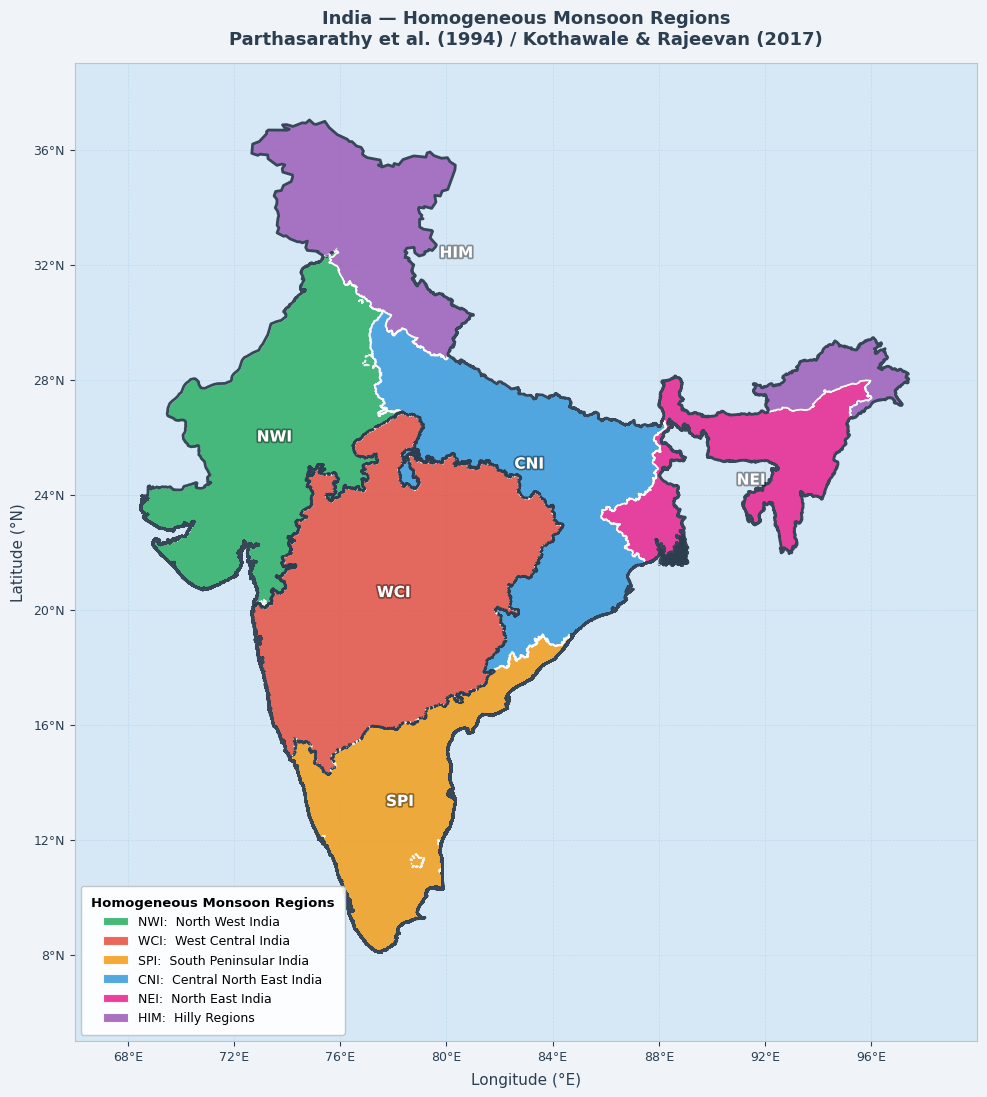

✓ Map saved: D:\PHD IIT KGP\7. Shapefiles\Homogeneous Monsoon Regions\India_HMR_Map.png


In [5]:
# ============================================================
# Plot India Homogeneous Monsoon Regions from Shapefiles
# ============================================================

import os
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import pandas as pd

os.environ['SHAPE_RESTORE_SHX'] = 'YES'   # handles missing .shx gracefully

# ══════════════════════════════════════════════════════════════
# ★  SET YOUR SHAPEFILE DIRECTORY AND OUTPUT PATH
SHP_DIR    = r"D:\PHD IIT KGP\7. Shapefiles\Homogeneous Monsoon Regions\SHAPEFILES_COPY"
OUTPUT_PNG = r"D:\PHD IIT KGP\7. Shapefiles\Homogeneous Monsoon Regions\India_HMR_Map.png"
# ══════════════════════════════════════════════════════════════

# Region config: (shapefile_stem, display_label, abbreviation, color)
REGIONS = [
    ("Northwest",         "North West India",         "NWI", "#27AE60"),
    ("West_Central",      "West Central India",       "WCI", "#E74C3C"),
    ("South_Peninsular",  "South Peninsular India",   "SPI", "#F39C12"),
    ("Central_Northeast", "Central North East India", "CNI", "#3498DB"),
    ("Northeast",         "North East India",         "NEI", "#E91E8C"),
    ("Hilly_Regions",     "Hilly Regions",            "HIM", "#9B59B6"),
]

# Fine-tune label positions if any overlap (x_offset, y_offset in degrees)
LABEL_OFFSETS = {
    "NWI": ( 0.0,  0.0),
    "WCI": ( 0.0,  0.0),
    "SPI": ( 0.0,  0.0),
    "CNI": ( 0.0,  0.5),
    "NEI": ( 0.3, -0.5),
    "HIM": ( 0.0,  0.0),
}

# ── Load and plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 11), facecolor='#F0F4F8')
ax.set_facecolor('#D6E8F5')   # ocean/background color

legend_patches = []
all_gdfs       = []
centroids      = []

for fname, label, abbr, color in REGIONS:
    shp_path = os.path.join(SHP_DIR, f"{fname}.shp")
    gdf = gpd.read_file(shp_path)

    # Assign WGS84 if CRS is missing
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    else:
        gdf = gdf.to_crs("EPSG:4326")

    # Plot filled region
    gdf.plot(ax=ax, color=color, edgecolor='white',
             linewidth=1.2, alpha=0.82, zorder=3)

    # Internal region boundaries
    gdf.boundary.plot(ax=ax, color='white',
                      linewidth=0.8, alpha=0.6, zorder=4)

    # Store centroid for labeling
    cx = gdf.geometry.iloc[0].centroid.x
    cy = gdf.geometry.iloc[0].centroid.y
    centroids.append((cx, cy, abbr, color))

    all_gdfs.append(gdf)
    legend_patches.append(
        mpatches.Patch(facecolor=color, alpha=0.85,
                       edgecolor='white', linewidth=0.8,
                       label=f"{abbr}:  {label}")
    )

# India outer boundary (dissolve all regions)
india_all     = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=True),
                                  crs="EPSG:4326")
india_outline = india_all.dissolve()
india_outline.boundary.plot(ax=ax, color='#2C3E50',
                             linewidth=2.0, zorder=5, alpha=0.95)

# Abbreviation labels on map
for (cx, cy, abbr, color) in centroids:
    ox, oy = LABEL_OFFSETS.get(abbr, (0, 0))
    ax.text(cx + ox, cy + oy, abbr,
            ha='center', va='center',
            fontsize=11, fontweight='bold',
            color='white', zorder=6,
            path_effects=[
                pe.Stroke(linewidth=2.5, foreground='#00000066'),
                pe.Normal()
            ])

# Legend
leg = ax.legend(handles=legend_patches,
                loc='lower left',
                fontsize=9,
                framealpha=0.92,
                facecolor='white',
                edgecolor='#BDC3C7',
                title='Homogeneous Monsoon Regions',
                title_fontsize=9.5,
                borderpad=0.8,
                labelspacing=0.5)
leg.get_title().set_fontweight('bold')

# Axis limits, labels, grid
ax.set_xlim(66, 100)
ax.set_ylim(5,  39)
ax.set_xticks(range(68, 100, 4))
ax.set_yticks(range(8,  40,  4))
ax.set_xticklabels([f'{x}°E' for x in range(68, 100, 4)], fontsize=8)
ax.set_yticklabels([f'{y}°N' for y in range(8,  40,  4)], fontsize=8)
ax.set_xlabel("Longitude (°E)", fontsize=11, labelpad=6, color='#2C3E50')
ax.set_ylabel("Latitude (°N)",  fontsize=11, labelpad=6, color='#2C3E50')
ax.tick_params(labelsize=9, colors='#2C3E50')
ax.grid(True, alpha=0.25, linewidth=0.5,
        color='#7FB3D3', linestyle='--', zorder=1)
for spine in ax.spines.values():
    spine.set_edgecolor('#BDC3C7')

ax.set_title(
    "India — Homogeneous Monsoon Regions\n"
    "Parthasarathy et al. (1994) / Kothawale & Rajeevan (2017)",
    fontsize=13, fontweight='bold', color='#2C3E50', pad=14
)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=180, bbox_inches='tight', facecolor='#F0F4F8')
plt.show()
print(f"✓ Map saved: {OUTPUT_PNG}")